# Assignment 1 — Environment & First Network

**DATAX504** · Due end of Week 2 · **NumPy only** (no Keras/TensorFlow for the network)

## Tasks
1. Document OpenCode setup (screenshot or log in `opencode_setup/` folder)
2. Train a 2-layer dense network on synthetic data below
3. Plot training loss over 100 epochs
4. Write a ~200-word reflection on OpenCode use

## Moodle fields
`a1_repo`, `a1_loss_final`, `a1_params`, `a1_opencode_model`, `a1_reflection`

## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool | OpenCode + Claude Sonnet 5 Anthropic |
| Used for |Assistance with sigmoid_derivative and simplification for (A2 - y) / m|
| Verified how | Wrote a verification function with help to check the long and short methods work out the same for determining the loss|
| Not used for | Checking shapes of arrays - understanding forward propogation and running existing code, or running for additional epochs |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(504)
plt.rcParams["figure.figsize"] = (8, 4) #8 wide, 4 tall

## 1. Synthetic dataset

Two moons–style binary classification in 2D (non-linear boundary).

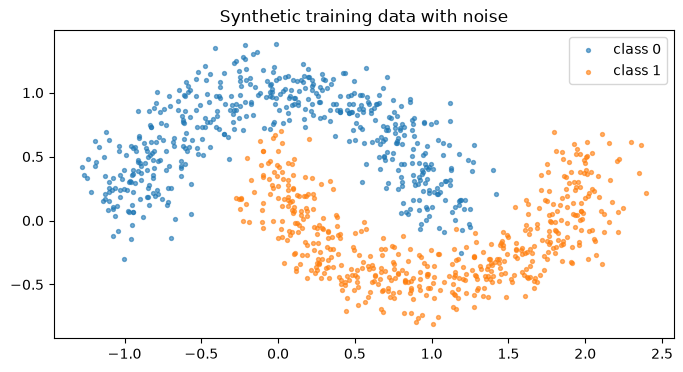

In [2]:
def make_moons(n_samples=1000,noise=0.15):
    """Simple two-moons dataset, Returns X (n,2),y(n,1)."""
    n = n_samples // 2 #n = 500
    theta = np.linspace(0,np.pi,n) #create angle values
    moon1 = np.c_[np.cos(theta),np.sin(theta)] #x,y co-ordinates for moon1
    moon2 = np.c_[1-np.cos(theta),1-np.sin(theta)-0.5]  #x,y co-ordinates for moon2
    X=np.vstack([moon1,moon2]) #X values 
    X += np.random.randn(*X.shape)*noise #add noise to X so it is not perfect crescents
    y=np.vstack([np.zeros((n,1)),np.ones((n,1))])  #y values 0 for moon1 1 for moon2
    return X.astype(np.float32),y.astype(np.float32)

X, y = make_moons(1000) #with noise
plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], s=8, alpha=0.6, label="class 0")
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], s=8, alpha=0.6, label="class 1")
plt.legend()
plt.title("Synthetic training data with noise")
plt.show()

## 2. Activation functions

In [3]:
def relu(x):
    return np.maximum(0,x)  #returns the larger of 0 or x - so converts all negatives to 0

def relu_derivative(x):
    return(x > 0).astype(np.float32) #0 when x is negative 1 when x is positive

def sigmoid(x):#used tto get probabability very -ve numbers close to 0 , 0 at .5 and very positive close to 1
    return 1/(1 + np.exp(-np.clip(x,-500,500)))

# TODO: implement sigmoid_derivative if you need it for backprop
def sigmoid_derivative(x):
    s = sigmoid(x) #compute sigmoid 0 to 1
    return s * (1 - s)  #get derivative


In [4]:
input_size, hidden_size, output_size = 2,16,1 #input 2, hidden 16, output 1
learning_rate = 0.1
epochs = 100 

W1 =np.random.randn(input_size,hidden_size).astype(np.float32)*np.sqrt(2/input_size) #random weights for initialization #shape (2,16)
print(W1.shape)
b1 = np.zeros((1,hidden_size),dtype=np.float32) #init bias b1 as 0  #shape(1,16)
print(b1.shape)

W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * 0.01 #random weights for initialization #shape (16,1)
print(W2.shape)
b2 = np.zeros((1, output_size), dtype=np.float32) #init bias b2 as 0  #shape(1,1)
print(b2.shape)

total_params = W1.size + b1.size + W2.size + b2.size
print(f"Total trainable parameters: {total_params}")  # → Moodle a1_params



(2, 16)
(1, 16)
(16, 1)
(1, 1)
Total trainable parameters: 65


## 4. Forward & backward pass

Implement one training step. Hint: binary cross-entropy loss gradient at sigmoid output simplifies to `(A2 - y) / m`.

In [5]:
def forward(X,W1,b1,W2,b2):
#Z1 is X with weights and bias
#A1 is relu(Z1)
#Z2 is A1 with weights and bias
#A2 is sigmoid(Z2) - the prediction
#We return out Z1,A1, A2    
    """Return cache dict with intermediates for backprop."""
    Z1 =X @W1 + b1  #X*weights 1 and bias 1
    A1 = relu(Z1)   #pass to relu function
    #X shape 1000,2
    #W1 shape 2,16
    #print(A1.shape) #1000,16
    Z2 = A1 @W2 + b2  #A1*weight2 and bias 2
    A2 = sigmoid(Z2) #pass to sigmoid function
    #W2 shape 16,1
    #print(A2.shape) #1000,1
    return {"Z1": Z1,"A1":A1,"A2":A2}

def backward (X,y,cache,W2):
    """Return gradeients dW1, db1, dW2, db2, """
    m=X.shape[0] #number of rows in X
    A1, A2 = cache["A1"], cache["A2"] #get A1 and A2 from forward pass
    dZ2 = (A2 -y)/m #dL/dz2 binary cross-entropy loss gradient for z2: (prediction-y)/rows binary cross-entropy loss gradient at sigmoid output simplifies to `(A2 - y) / m`.
    dW2 = A1.T @ dZ2 #dL/dW2 correction for each W2 weight - transpose A1 and multiply by dZ2 
    db2 = np.sum(dZ2, axis=0, keepdims=True) #dL/db2 correction for bias
    dA1 = dZ2 @ W2.T  #dL/dA1 
    dZ1 = dA1 * relu_derivative(cache["Z1"]) #dL/dz1
    dW1 = X.T @ dZ1 #dL/dW1
    db1 = np.sum(dZ1, axis=0, keepdims=True) #dL/db1
    return dW1, db1, dW2, db2

def compute_loss(y, A2): #binary cross entropy
    eps = 1e-8
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))    

## 5. Training loop

In [6]:
loss_history = []

for epoch in range(epochs):
    cache = forward(X, W1, b1, W2, b2)
    loss = compute_loss(y, cache["A2"])
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward(X, y, cache, W2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  loss = {loss:.4f}")

final_loss = loss_history[-1]
print(f"\nFinal loss (Moodle a1_loss_final): {final_loss:.4f}")

Epoch   0  loss = 0.6900
Epoch  20  loss = 0.4705
Epoch  40  loss = 0.3826
Epoch  60  loss = 0.3383
Epoch  80  loss = 0.3126

Final loss (Moodle a1_loss_final): 0.2969


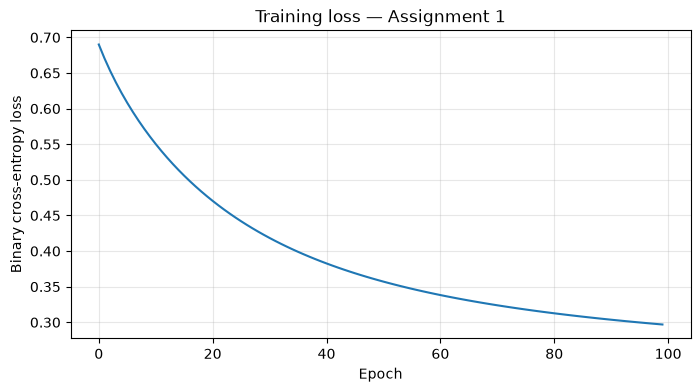

In [7]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss — Assignment 1")
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Predictions: threshold A2 at 0.5 to get class labels
final_cache = forward(X, W1, b1, W2, b2)
predictions = (final_cache["A2"] > 0.5).astype(np.float32)

accuracy = np.mean(predictions == y)
print(f"Training accuracy: {accuracy * 100:.2f}%")



Training accuracy: 86.50%


In [9]:
# Fresh init, identical to assignment's init — just testing more epochs
np.random.seed(504)

W1_exp = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2/input_size)
print(W1_exp.shape)
b1_exp = np.zeros((1, hidden_size), dtype=np.float32)
print(b1_exp.shape)
W2_exp = np.random.randn(hidden_size, output_size).astype(np.float32) * 0.01
print(W2_exp.shape)
b2_exp = np.zeros((1, output_size), dtype=np.float32)
print(b2_exp.shape)

epochs_exp = 2000

for epoch in range(epochs_exp):
    cache = forward(X, W1_exp, b1_exp, W2_exp, b2_exp)
    dW1, db1, dW2, db2 = backward(X, y, cache, W2_exp)
    W1_exp -= learning_rate * dW1
    b1_exp -= learning_rate * db1
    W2_exp -= learning_rate * dW2
    b2_exp -= learning_rate * db2
    if epoch % 400 == 0:
        loss = compute_loss(y, cache["A2"])
        print(f"Epoch {epoch}: loss = {loss:.4f}")

final_exp = forward(X, W1_exp, b1_exp, W2_exp, b2_exp)
preds_exp = (final_exp["A2"] > 0.5).astype(np.float32)
print(f"Accuracy: {np.mean(preds_exp == y)*100:.2f}%")
print((final_cache["A1"] == 0).mean())   # what fraction of hidden activations are exactly zero

(2, 16)
(1, 16)
(16, 1)
(1, 1)
Epoch 0: loss = 0.6905
Epoch 400: loss = 0.2576
Epoch 800: loss = 0.2186
Epoch 1200: loss = 0.1715
Epoch 1600: loss = 0.1242
Accuracy: 97.80%
0.4815625


In [10]:
# Standalone verification: does sigmoid_derivative + full chain rule
# give the same dZ2 as the shortcut (A2 - y) / m ?

cache = forward(X, W1, b1, W2, b2)
A1, A2 = cache["A1"], cache["A2"]
m = X.shape[0]

# Recompute Z2 directly — we have full access to W2 and b2 here
Z2 = A1 @ W2 + b2

# The "long way": explicit chain rule, calling sigmoid_derivative directly
dL_dA2 = -(y / A2) + (1 - y) / (1 - A2)     # dL/da2 — loss's own derivative
da2_dZ2 = sigmoid_derivative(Z2)             # da2/dz2 — sigmoid's own derivative
dZ2_long_way = (dL_dA2 * da2_dZ2) / m

# The shortcut, exactly as used in backward()
dZ2_shortcut = (A2 - y) / m

print("Long way, first 5:", dZ2_long_way[:5].ravel())
print("Shortcut, first 5:", dZ2_shortcut[:5].ravel())

Long way, first 5: [0.00063398 0.00077471 0.00069699 0.00062278 0.00067263]
Shortcut, first 5: [0.00063398 0.00077471 0.00069699 0.00062278 0.00067263]


## 6. Reflection (Moodle `a1_reflection`)

Write ~200 words:
- One thing OpenCode helped with
- One thing it got wrong or you had to fix
- How you verified the final notebook

Open Code helped me understand the simplification of the dL/dZ2 - loss with respect to the output - simplifies to (A2 -y)/m.  
This contains the sigmoid_derivative so it is not needed as a separate function for backprop . 
I needed help stepping through the calculus to show that:
dZ2 = (A2 -y)/m 

Is the same as:
dL/dZ2 = dL/dA2*dA2/dZ2

dA2/dZ2 is the sigmoid derivative A2(1-A2)

dL/dA2*dA2/dZ2 - simplifies to (A2-y)/m so you don't need to use the sigmoid derivative.

Verification: I did a couple of worked through forward and backprop examples on paper to help me understand the process.
I checked the model loss was going down and ran for more epochs to check it got better
I did the calculation for dL/dZ2 = dL/dA2*dA2/dZ2 and compared to (A2-y)/m to prove this worked along with a function to show it comes out the same:

Long way, first 5: [0.00063398 0.00077471 0.00069699 0.00062278 0.00067263]

Shortcut, first 5: [0.00063398 0.00077471 0.00069699 0.00062278 0.00067263]

One thing I got wrong:
I was playing around with make_moons to see how it looked with noise and no_noise and accidentally affected the final training loss - so made sure I cleaned all that up before submission.